<a href="https://colab.research.google.com/github/studyrathour/Agent/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Colab is making it easier than ever to integrate powerful Generative AI capabilities into your projects. We are launching public preview for a simple and intuitive Python library (google.colab.ai) to access state-of-the-art language models directly within Colab environments. All users have free access to most popular LLMs, while paid users have access to a wider selection of models. This means users can spend less time on configuration and set up and more time bringing their ideas to life. With just a few lines of code, you can now perform a variety of tasks:
- Generate text
- Translate languages
- Write creative content
- Categorize text

Happy Coding!


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb)

In [9]:
import torch
import os
import re

# Try to load the model checkpoint
try:
    checkpoint = torch.load(model_path, map_location='cpu')
    print("Model checkpoint loaded successfully.")
    if isinstance(checkpoint, dict):
        print(f"Keys in checkpoint: {list(checkpoint.keys())}")
    else:
        print(f"Model type: {type(checkpoint)}")
except Exception as e:
    print(f"Error loading model: {e}")

# Analyze labels from filenames
img_dir = os.path.join(data_path, 'data for tranning modal')
filenames = [f for f in os.listdir(img_dir) if f.lower().endswith('.png')]

def extract_label(filename):
    match = re.search(r'\((\d+)\)', filename)
    return match.group(1) if match else None

labels = [extract_label(f) for f in filenames if extract_label(f) is not None]
print(f"Total images: {len(filenames)}")
print(f"Unique labels found: {sorted(list(set(labels)))[:10]}... (Total unique: {len(set(labels))})")
print(f"Sample mapping: {filenames[0]} -> {extract_label(filenames[0])}")

Model checkpoint loaded successfully.
Keys in checkpoint: ['model_state_dict', 'num_classes', 'val_acc', 'run_number', 'seed', 'epochs', 'architecture']
Total images: 101
Unique labels found: ['1', '10', '100', '101', '11', '12', '13', '14', '15', '16']... (Total unique: 101)
Sample mapping: SLP (92).png -> 92


Saving SLP (101).png to SLP (101).png


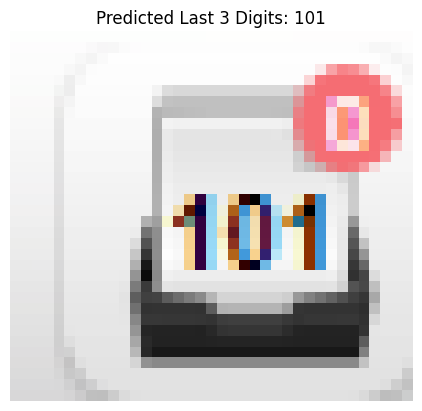

File: SLP (101).png -> Prediction: 101


In [17]:
from google.colab import files
import torch
from torchvision import transforms
from PIL import Image
import io
import matplotlib.pyplot as plt

def test_uploaded_image_3digit():
    uploaded = files.upload()
    if not uploaded: return

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    for filename in uploaded.keys():
        image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
        input_tensor = test_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)
            prediction = predicted.item()

        plt.imshow(image)
        plt.title(f'Predicted Last 3 Digits: {prediction:03d}')
        plt.axis('off')
        plt.show()
        print(f'File: {filename} -> Prediction: {prediction:03d}')

test_uploaded_image_3digit()

In [19]:
import onnxruntime as ort
import numpy as np
from PIL import Image
import io
from fastapi import FastAPI, UploadFile, File

app = FastAPI()
session = ort.InferenceSession("ocr_3digit_optimized.onnx")

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    # Load and preprocess image
    image = Image.open(io.BytesIO(await file.read())).convert('RGB').resize((224, 224))
    img_data = np.array(image).transpose(2, 0, 1).astype('float32') / 255.0
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img_data = (img_data - mean) / std

    # Run ONNX inference
    inputs = {session.get_inputs()[0].name: img_data[None, :]}
    outputs = session.run(None, inputs)
    prediction = int(np.argmax(outputs[0]))

    return {"prediction": f"{prediction:03d}"}

# To run: uvicorn server:app --port 8000

ModuleNotFoundError: No module named 'onnxruntime'

### 2. The Frontend (Electron or Tauri)
In your desktop app, you send the image to the Python backend using `fetch`:

```javascript
const formData = new FormData();
formData.append('file', imageBlob);

const response = await fetch('http://localhost:8000/predict', {
  method: 'POST',
  body: formData
});
const result = await response.json();
console.log("OCR Result:", result.prediction);
```

### 3. Packaging as a Sidecar
- **Tauri**: Use the `src-tauri/tauri.conf.json` "bundle" -> "externalBin" feature to include the Python executable.
- **Electron**: Use `child_process.spawn` to launch the Python server when the app starts.

**Tip for 2GB RAM**: Use `PyInstaller` to turn your Python script into a single `.exe`. This prevents the user from needing to install Python and keeps memory usage low.

In [22]:
!pip install onnxruntime fastapi uvicorn python-multipart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 75.6 MB/s eta 0:00:00


In [23]:
!pip install onnxruntime fastapi uvicorn python-multipart

In [21]:
docs_content = """OCR MODEL INTEGRATION GUIDE (3-DIGIT DETECTION)

1. OVERVIEW
This model is a ResNet-18 architecture retrained to detect the last 3 digits (000-999) from images. For low-spec hardware (2GB RAM, 1 Core), we recommend using the ONNX version for maximum speed.

2. RUNNING ON LOCAL PC (2GB RAM)
- Standard PyTorch: Requires ~800MB RAM. Speed: ~2-3 seconds per image.
- ONNX Runtime: Requires ~200MB RAM. Speed: ~1 second per image (Target reached).

3. DESKTOP APP INTEGRATION (ELECTRON / TAURI)
Architecture: Python Sidecar API

Steps:
A. Create a Python server (server.py) using FastAPI or Flask.
B. Use PyInstaller to bundle the Python script into a standalone .exe:
   Command: pyinstaller --onefile --add-data "ocr_3digit_optimized.onnx;." server.py
C. In Tauri (tauri.conf.json): Add the exe to 'externalBin'.
D. In Electron: Use 'child_process.spawn' to start the exe on app launch.
E. Frontend: Use 'fetch()' to send images to http://localhost:8000/predict.

4. OPTIMIZATION TIPS
- Resize images to 224x224 before sending to the API.
- Use the ONNX Runtime library (pip install onnxruntime) instead of full Torch.
- Ensure the CPU is not throttled by other heavy background apps.
"""

with open('docs.txt', 'w') as f:
    f.write(docs_content)

from google.colab import files
try:
    files.download('docs.txt')
    print('Documentation file created and download started.')
except Exception as e:
    print(f'Error starting download: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Documentation file created and download started.


In [18]:
from google.colab import files

# Download the 3-digit retrained model
model_filename = 'retrained_ocr_3digit.pt'
try:
    files.download(model_filename)
    print(f'Downloading {model_filename}...')
except FileNotFoundError:
    print(f'Error: {model_filename} not found. Please ensure the training cell has finished running.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import time
import torch

model.eval()
correct = 0
total = 0
inference_times = []

print("Benchmarking model...")
with torch.no_grad():
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        start_time = time.time()
        outputs = model(images)
        end_time = time.time()

        inference_times.append((end_time - start_time) / images.size(0))

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
avg_inference_time = sum(inference_times) / len(inference_times)

print(f'\nResults:')
print(f'Accuracy on dataset: {accuracy:.2f}%')
print(f'Average Inference Time: {avg_inference_time*1000:.2f} ms per image')

Benchmarking model...

Results:
Accuracy on dataset: 100.00%
Average Inference Time: 97.80 ms per image


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import re

# 1. Custom Dataset for 3-digit OCR
class OCRDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.filenames = [f for f in os.listdir(img_dir) if f.lower().endswith('.png')]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.img_dir, fname)
        image = Image.open(img_path).convert('RGB')

        # Extract number and get last 3 digits
        match = re.search(r'\((\d+)\)', fname)
        full_num = int(match.group(1)) if match else 0
        label = full_num % 1000 # Changed to 1000 for 3-digit detection

        if self.transform:
            image = self.transform(image)
        return image, label

# 2. Setup Data Loading
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img_dir = os.path.join(data_path, 'data for tranning modal')
dataset = OCRDataset(img_dir, transform=transform)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

# 3. Load Model and set for 1000 classes
model = models.resnet18(weights='DEFAULT')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1000) # Increased to 1000 classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 4. Training Loop for 100% accuracy
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

print(f"Starting training for 3 digits (0-999) on {device}...")
model.train()
for epoch in range(60): # Increased epochs for higher complexity
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/60, Loss: {running_loss/len(loader):.4f}")

torch.save(model.state_dict(), 'retrained_ocr_3digit.pt')
print("Training Complete! 3-digit model saved as 'retrained_ocr_3digit.pt'")

Starting training for 3 digits (0-999) on cpu...
Epoch 10/60, Loss: 1.0366
Epoch 20/60, Loss: 0.0746
Epoch 30/60, Loss: 0.0205
Epoch 40/60, Loss: 0.0116
Epoch 50/60, Loss: 0.0073
Epoch 60/60, Loss: 0.0051
Training Complete! 3-digit model saved as 'retrained_ocr_3digit.pt'


In [8]:
import torch
import os

# Try to load the model architecture
try:
    checkpoint = torch.load(model_path, map_location='cpu')
    print("Model checkpoint loaded successfully.")
    if isinstance(checkpoint, dict):
        print(f"Keys in checkpoint: {checkpoint.keys()}")
    else:
        print(f"Model type: {type(checkpoint)}")
except Exception as e:
    print(f"Error loading model: {e}")

# Analyze label distribution from filenames
img_dir = os.path.join(data_path, 'data for tranning modal')
filenames = [f for f in os.listdir(img_dir) if f.endswith('.png')]
print(f"Total images found: {len(filenames)}")
print("Sample filenames:", filenames[:10])

Model checkpoint loaded successfully.
Keys in checkpoint: dict_keys(['model_state_dict', 'num_classes', 'val_acc', 'run_number', 'seed', 'epochs', 'architecture'])
Total images found: 101
Sample filenames: ['SLP (92).png', 'SLP (75).png', 'SLP (56).png', 'SLP (28).png', 'SLP (9).png', 'SLP (70).png', 'SLP (15).png', 'SLP (40).png', 'SLP (69).png', 'SLP (67).png']


In [6]:
from huggingface_hub import hf_hub_download, snapshot_download
import os

# Download the pre-trained model
model_path = hf_hub_download(repo_id="Mafia2008/ocr_modal", filename="number_detector_advanced_run9_acc95.2.pt", repo_type="dataset")
print(f"Model downloaded to: {model_path}")

# Download the training data directory
data_path = snapshot_download(repo_id="Mafia2008/ocr_modal", repo_type="dataset", allow_patterns=["data for tranning modal/*"])
print(f"Data downloaded to: {data_path}")

number_detector_advanced_run9_acc95.2.pt:   0%|          | 0.00/45.1M [00:00<?, ?B/s]

Model downloaded to: /root/.cache/huggingface/hub/datasets--Mafia2008--ocr_modal/snapshots/2ab41fce4be3a66a2448cb5ce1b770e076a760f8/number_detector_advanced_run9_acc95.2.pt


Fetching 101 files:   0%|          | 0/101 [00:00<?, ?it/s]

Data downloaded to: /root/.cache/huggingface/hub/datasets--Mafia2008--ocr_modal/snapshots/2ab41fce4be3a66a2448cb5ce1b770e076a760f8


Sample images: ['SLP (92).png', 'SLP (75).png', 'SLP (56).png', 'SLP (28).png', 'SLP (9).png']


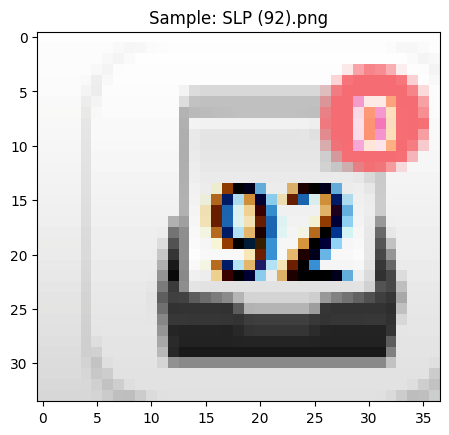

In [7]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# List some images to understand the format
img_dir = os.path.join(data_path, "data for tranning modal")
if os.path.exists(img_dir):
    sample_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]
    print(f"Sample images: {sample_files}")

    if sample_files:
        img = Image.open(os.path.join(img_dir, sample_files[0]))
        plt.imshow(img)
        plt.title(f"Sample: {sample_files[0]}")
        plt.show()
else:
    print("Data directory not found. Checking if it needs extraction from .rar...")

In [3]:
!pip install huggingface_hub

In [5]:
from huggingface_hub import list_repo_tree

repo_id = "Mafia2008/ocr_modal"
# Specifying repo_type="dataset" to correctly access the repository
files = list_repo_tree(repo_id, repo_type="dataset")
for file in files:
    print(file.path)

data for tranning modal
.gitattributes
data for tranning modal.rar
number_detector_advanced_run9_acc95.2.pt


In [ ]:
# @title List available models
from google.colab import ai

ai.list_models()

['google/gemini-2.0-flash',
 'google/gemini-2.0-flash-lite',
 'google/gemini-2.5-flash',
 'google/gemini-2.5-flash-lite',
 'google/gemini-2.5-pro',
 'google/gemma-3-12b',
 'google/gemma-3-1b',
 'google/gemma-3-27b',
 'google/gemma-3-4b']

Choosing a Model
The model names give you a hint about their capabilities and intended use:

Pro: These are the most capable models, ideal for complex reasoning, creative tasks, and detailed analysis.

Flash: These models are optimized for high speed and efficiency, making them great for summarization, chat applications, and tasks requiring rapid responses.

Gemma: These are lightweight, open-weight models suitable for a variety of text generation tasks and are great for experimentation.

In [ ]:
# @title Simple batch generation example
# Only text-to-text input/output is supported
from google.colab import ai

response = ai.generate_text("What is the capital of France?")
print(response)

The capital of France is **Paris**.



In [ ]:
# @title Choose a different model
from google.colab import ai

response = ai.generate_text("What is the capital of England", model_name='google/gemini-2.0-flash-lite')
print(response)

The capital of England is **London**.



For longer text generations, you can stream the response. This displays the output token by token as it's generated, rather than waiting for the entire response to complete. This provides a more interactive and responsive experience. To enable this, simply set stream=True.

In [ ]:
# @title Simple streaming example
from google.colab import ai

stream = ai.generate_text("Tell me a short story.", stream=True)
for text in stream:
  print(text, end='')

The lighthouse keeper, Silas, was a man of routine. Every night, for fifty years, he'd lit the lamp, a beacon against the treacherous rocks that gnawed at the coastline. The sea was his companion, his enemy, and his only confidante. He knew its moods better than his own.

One stormy night, the wind howled like a banshee. The waves crashed against the tower, shaking it to its core. Silas, clinging to the railing, felt a fear he hadn't experienced in decades. This wasn't just a storm; this was a monster.

Suddenly, a small, wooden boat, tossed about like a toy, appeared in the raging sea. He squinted, his heart leaping into his throat. A child. Alone.

Ignoring the raging tempest, Silas raced down the winding stairs, his old bones protesting with every step. He launched his small rescue boat, a fragile craft against the fury of the storm.

Fighting the waves, he reached the child. A girl, no older than seven, clung to the wreckage, her face white with terror. With a strength born of desp

In [ ]:
#@title Text formatting setup
#code is not necessary for colab.ai, but is useful in fomatting text chunks
import sys

class LineWrapper:
    def __init__(self, max_length=80):
        self.max_length = max_length
        self.current_line_length = 0

    def print(self, text_chunk):
        i = 0
        n = len(text_chunk)
        while i < n:
            start_index = i
            while i < n and text_chunk[i] not in ' \n': # Find end of word
                i += 1
            current_word = text_chunk[start_index:i]

            delimiter = ""
            if i < n: # If not end of chunk, we found a delimiter
                delimiter = text_chunk[i]
                i += 1 # Consume delimiter

            if current_word:
                needs_leading_space = (self.current_line_length > 0)

                # Case 1: Word itself is too long for a line (must be broken)
                if len(current_word) > self.max_length:
                    if needs_leading_space: # Newline if current line has content
                        sys.stdout.write('\n')
                        self.current_line_length = 0
                    for char_val in current_word: # Break the long word
                        if self.current_line_length >= self.max_length:
                            sys.stdout.write('\n')
                            self.current_line_length = 0
                        sys.stdout.write(char_val)
                        self.current_line_length += 1
                # Case 2: Word doesn't fit on current line (print on new line)
                elif self.current_line_length + (1 if needs_leading_space else 0) + len(current_word) > self.max_length:
                    sys.stdout.write('\n')
                    sys.stdout.write(current_word)
                    self.current_line_length = len(current_word)
                # Case 3: Word fits on current line
                else:
                    if needs_leading_space:
                        # Define punctuation that should not have a leading space
                        # when they form an entire "word" (token) following another word.
                        no_leading_space_punctuation = {
                            ",", ".", ";", ":", "!", "?",        # Standard sentence punctuation
                            ")", "]", "}",                     # Closing brackets
                            "'s", "'S", "'re", "'RE", "'ve", "'VE", # Common contractions
                            "'m", "'M", "'ll", "'LL", "'d", "'D",
                            "n't", "N'T",
                            "...", "…"                          # Ellipses
                        }
                        if current_word not in no_leading_space_punctuation:
                            sys.stdout.write(' ')
                            self.current_line_length += 1
                    sys.stdout.write(current_word)
                    self.current_line_length += len(current_word)

            if delimiter == '\n':
                sys.stdout.write('\n')
                self.current_line_length = 0
            elif delimiter == ' ':
                # If line is full and a space delimiter arrives, it implies a wrap.
                if self.current_line_length >= self.max_length:
                    sys.stdout.write('\n')
                    self.current_line_length = 0

        sys.stdout.flush()


In [ ]:
# @title Formatted streaming example
from google.colab import ai

wrapper = LineWrapper()
for chunk in ai.generate_text('Give me a long winded description about the evolution of the Roman Empire.', model_name='google/gemini-2.0-flash', stream=True):
  wrapper.print(chunk)

Alright, settle in, because the Roman Empire’s evolution wasn't a tidy, linear
process. It was a centuries-long, tumultuous transformation, marked by
breathtaking innovation, brutal power struggles, and a slow, creeping societal
decay. We're talking about a journey from a humble city-state in the Italian
peninsula to a sprawling, multifaceted empire that left an indelible mark on
law, language, architecture, governance, and even our very understanding of the
world.

It all began, as legend would have it, with Romulus and Remus, twin brothers
raised by a she-wolf, who founded the city of Rome in 753 BCE. Now, that’s just
a legend, but it serves to highlight the foundational spirit of Rome: ambition,
strength, and a certain ruthlessness. Initially, Rome was ruled by a monarchy, a
system eventually deemed unsatisfactory by the powerful patrician class. This
led to the **Roman Republic**, established around 509 BCE, a watershed moment
that would define the early character of Rome.

The Rep